Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset downloaded to:
/kaggle/input/customer-segmentation-tutorial-in-python

Dataset Found:
/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv

First 5 Rows:

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (200, 5)


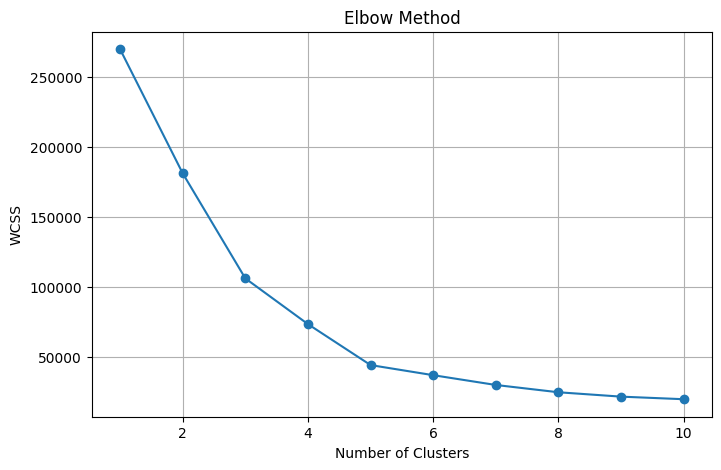


Cluster Centers:

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

Customers in Each Cluster:

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Clustered dataset saved as: Customer_Segments.csv


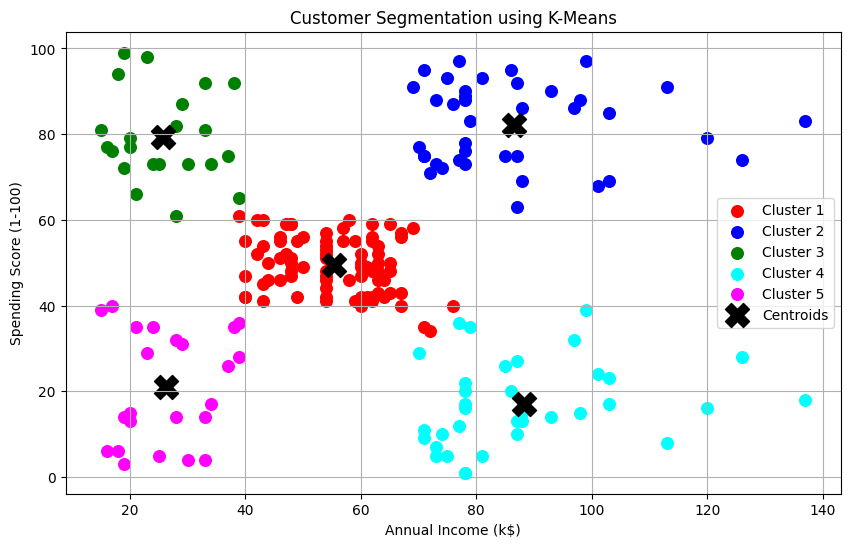


First 10 Customers with Cluster Labels:

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  


In [3]:
# ============================================================
# Customer Segmentation using K-Means Clustering
# ============================================================

import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# Step 1: Download Dataset
# ------------------------------------------------------------

print("Downloading dataset from Kaggle...")

path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Dataset downloaded to:")
print(path)

# ------------------------------------------------------------
# Step 2: Find Mall_Customers.csv Automatically
# ------------------------------------------------------------

csv_file = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if csv_file is None:
    raise FileNotFoundError("Mall_Customers.csv not found!")

print("\nDataset Found:")
print(csv_file)

# ------------------------------------------------------------
# Step 3: Load Dataset
# ------------------------------------------------------------

df = pd.read_csv(csv_file)

print("\nFirst 5 Rows:\n")
print(df.head())

print("\nDataset Shape:", df.shape)

# ------------------------------------------------------------
# Step 4: Select Features
# ------------------------------------------------------------

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ------------------------------------------------------------
# Step 5: Elbow Method
# ------------------------------------------------------------

wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Step 6: Train Final Model
# ------------------------------------------------------------

k = 5   # Optimal number of clusters

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

# ------------------------------------------------------------
# Step 7: Add Cluster Labels
# ------------------------------------------------------------

df["Cluster"] = labels

print("\nCluster Centers:\n")
print(kmeans.cluster_centers_)

print("\nCustomers in Each Cluster:\n")
print(df["Cluster"].value_counts().sort_index())

# ------------------------------------------------------------
# Step 8: Save Output
# ------------------------------------------------------------

output_file = "Customer_Segments.csv"
df.to_csv(output_file, index=False)

print(f"\nClustered dataset saved as: {output_file}")

# ------------------------------------------------------------
# Step 9: Visualize Clusters
# ------------------------------------------------------------

colors = [
    'red','blue','green','cyan','magenta',
    'yellow','orange','purple','brown','pink'
]

plt.figure(figsize=(10,6))

for i in range(k):
    plt.scatter(
        X.iloc[labels == i, 0],
        X.iloc[labels == i, 1],
        s=70,
        color=colors[i],
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Step 10: Display Sample Results
# ------------------------------------------------------------

print("\nFirst 10 Customers with Cluster Labels:\n")
print(df.head(10))